In [269]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml
from sklearn.tree import DecisionTreeClassifier, plot_tree



In [246]:
cardio = fetch_openml(data_id=45547, as_frame=True)
df = cardio.frame
X, y = cardio.data, cardio.target

In [247]:
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,2,168,62.0,110.0,80.0,1,1,0,0,1,0
1,20228,1,156,85.0,140.0,90.0,3,1,0,0,1,1
2,18857,1,165,64.0,130.0,70.0,3,1,0,0,0,1
3,17623,2,169,82.0,150.0,100.0,1,1,0,0,1,1
4,17474,1,156,56.0,100.0,60.0,1,1,0,0,0,0


In [248]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   age          70000 non-null  int64   
 1   gender       70000 non-null  category
 2   height       70000 non-null  int64   
 3   weight       70000 non-null  float64 
 4   ap_hi        70000 non-null  float64 
 5   ap_lo        70000 non-null  float64 
 6   cholesterol  70000 non-null  category
 7   gluc         70000 non-null  category
 8   smoke        70000 non-null  category
 9   alco         70000 non-null  category
 10  active       70000 non-null  category
 11  cardio       70000 non-null  category
dtypes: category(7), float64(3), int64(2)
memory usage: 3.1 MB


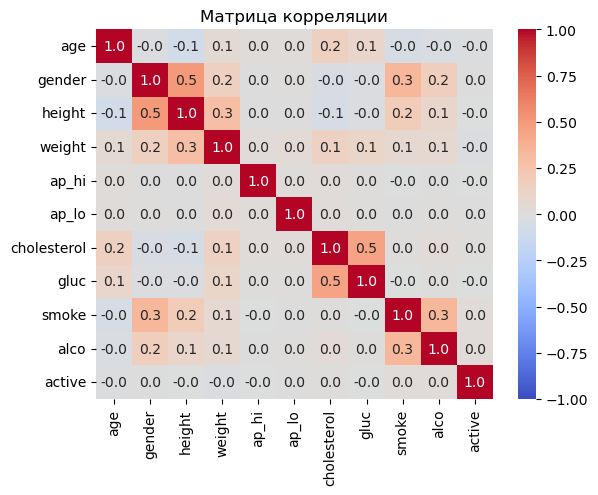

In [249]:
corr_matrix = X.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".1f")

plt.title("Матрица корреляции")
plt.show()

In [250]:
# df['gender'] = df['gender'].cat.codes #0 - women; 1 - men
# df['cholesterol'] = df['cholesterol'].cat.codes
# df['gluc'] = df['gluc'].cat.codes 
# df['smoke'] = df['smoke'].cat.codes
# df['alco'] = df['alco'].cat.codes
# df['active'] = df['active'].cat.codes
# df['cardio'] = df['cardio'].cat.codes
X = pd.get_dummies(X)

In [251]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   age          70000 non-null  int64   
 1   gender       70000 non-null  category
 2   height       70000 non-null  int64   
 3   weight       70000 non-null  float64 
 4   ap_hi        70000 non-null  float64 
 5   ap_lo        70000 non-null  float64 
 6   cholesterol  70000 non-null  category
 7   gluc         70000 non-null  category
 8   smoke        70000 non-null  category
 9   alco         70000 non-null  category
 10  active       70000 non-null  category
 11  cardio       70000 non-null  category
dtypes: category(7), float64(3), int64(2)
memory usage: 3.1 MB


In [252]:
df.isna().sum()

age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

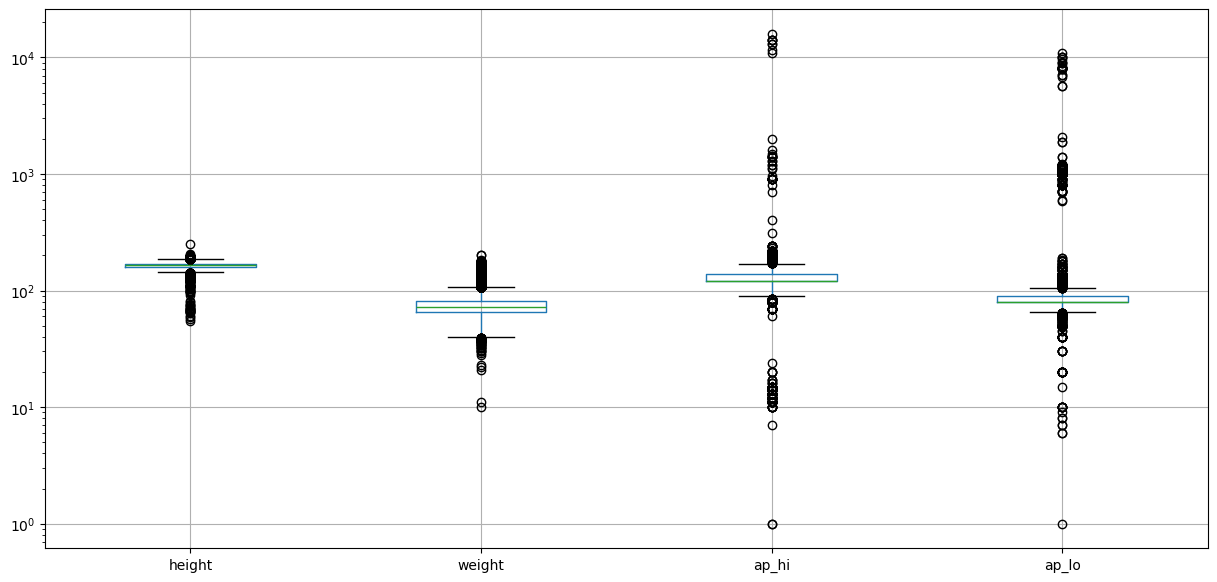

In [253]:
plt.figure(figsize = (15,7))
X.iloc[:,1:5].boxplot()
plt.yscale("log")

In [254]:
df.describe()

,age,height,weight,ap_hi,ap_lo
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,164.359229,74.205690,128.817286,96.630414
std,2467.251667,8.210126,14.395757,154.011419,188.472530
min,10798.000000,55.000000,10.000000,-150.000000,-70.000000
25%,17664.000000,159.000000,65.000000,120.000000,80.000000
50%,19703.000000,165.000000,72.000000,120.000000,80.000000
75%,21327.000000,170.000000,82.000000,140.000000,90.000000
max,23713.000000,250.000000,200.000000,16020.000000,11000.000000


<Axes: >

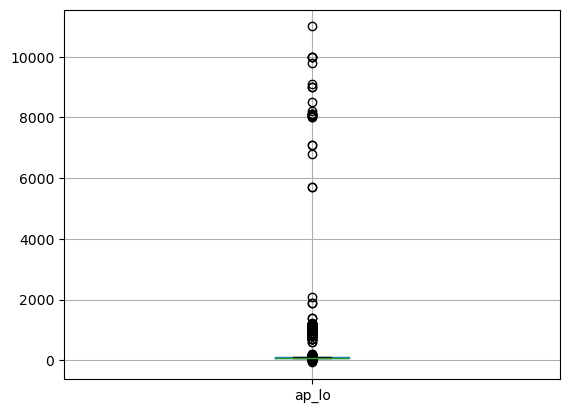

In [255]:
X.iloc[:,[4]].boxplot()

In [256]:
X['ap_lo'].quantile(.95)

np.float64(100.0)

In [257]:
ind = X[X['ap_lo']<40].index
X = X.drop(ind)
y = y.drop(ind)
ind = X[X['ap_lo']>X['ap_lo'].quantile(.95)].index
X = X.drop(ind)
y = y.drop(ind)
ind = X[X['ap_hi']>X['ap_hi'].quantile(.95)].index
X = X.drop(ind)
y = y.drop(ind)
ind = X[X['ap_hi']<60].index
X = X.drop(ind)
y = y.drop(ind)

<Axes: >

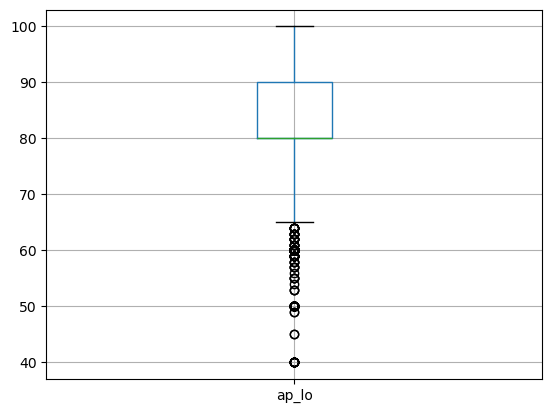

In [258]:
X.iloc[:,[4]].boxplot()

In [264]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, stratify = y)
print(y_train)

22611    1
51432    1
11341    0
18790    1
29534    1
        ..
51890    1
56096    0
2671     0
33851    0
59493    0
Name: cardio, Length: 50032, dtype: category
Categories (2, str): ['0', '1']


In [271]:
model = DecisionTreeClassifier(max_depth = 5, random_state = 42)
model.fit(X_train, y_train)
pred = model.predict(X_test)
accuracy = accuracy_score(y_test, pred)
precision = precision_score(y_test, pred)
print(accuracy, precision)

ValueError: pos_label=1 is not a valid label. It should be one of ['0', '1']